In [1]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass
password = getpass.getpass("Introduce la contraseña MySQL: ")

conn = mysql.connector.connect(
    host="212.227.90.6",
    user="Equipo26",
    password=password,
    database="Equip_26"
)

df_rat_precio = pd.read_sql("SELECT * FROM copy_ta04052026", conn)
conn.close()

print("Conexión exitosa ✅")
print(f"Datos cargados: {df_rat_precio.shape[0]} filas, {df_rat_precio.shape[1]} columnas")

C:\Users\ruben\AppData\Local\Temp\ipykernel_25180\912327522.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rat_precio = pd.read_sql("SELECT * FROM copy_ta04052026", conn)


Conexión exitosa ✅
Datos cargados: 9650 filas, 38 columnas


<span style="font-size: 1.5em;">DATA CLEANNING</span>

<span style="font-size: 1.5em;">En primer lugar, filtraremos en Dataset teniendo en cuenta las valoraciones de las diferentes dimemensiones, el rating general y el precio. Nos quedaremos solamente con los alojamientos que cuenten con información en todas las variables.</span>

In [2]:
v_independientes = ['price_imputed','review_scores_cleanliness', 'review_scores_accuracy', 
               'review_scores_communication', 'review_scores_checkin']

df_filtrado_price = df_rat_precio[
    (df_rat_precio['review_scores_rating_clean'].notnull()) & 
    (df_rat_precio[v_independientes].notnull().all(axis=1))
].copy()

df_filtrado_price

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,review_scores_rating_clean,price_imputed,neighbourhood_name_clean
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,None,Private room,2,2,1,...,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018,97.0,400.0,centro
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1,1,...,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020,92.0,170.0,cármenes
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2,...,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019,98.0,990.0,san vicente
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2,1,...,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020,94.0,400.0,l'antiga esquerra de l'eixample
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,None,Private room,5,1,2,...,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019,97.0,900.0,quart
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9628,46060050,Maravilloso apartamento en Chueca,Al�jate en este piso de dos dormitorios y capa...,372658950,Justicia,Centro,Entire home/apt,4,2,2,...,100.0,90.0,VERDADERO,17.0,spain,madrid,09/02/2021,100.0,730.0,justicia
9634,46615731,Habitacion econ�mica centrica plaza espa�a.,"Habitaci�n con cama sencilla, ventana hacia el...",376852626,Hostafrancs,Sants-Montju�c,Private room,1,2,1,...,100.0,100.0,VERDADERO,10.0,spain,barcelona,16/12/2020,100.0,210.0,hostafrancs
9637,46749230,Habitaci�n Grande PLENO CENTRO a 1km de Playa+...,Habitaci�n privada con cama doble o camas sepa...,276500587,Centro,None,Private room,4,2,1,...,100.0,100.0,VERDADERO,20.0,spain,malaga,31/01/2021,100.0,170.0,centro
9639,46984837,APARTAMENTO INDEPENDIENTE DE ESTILO SEVILLANO,"Zona c�ntrica con todo tipo de trasporte, come...",240047311,Ciudad Jard�n,Nervi�n,Entire home/apt,4,2,1,...,100.0,100.0,FALSO,176.0,spain,sevilla,27/02/2021,100.0,260.0,ciudad jardín


<span style="font-size: 1.5em;">Calculamos las correlaciones de Pearson y Sperman.</span>

In [3]:
# Cálculo correlación de Pearson
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# 1. Selección de las variables de interés
precio = df_filtrado_price['price_imputed']
rating = df_filtrado_price['review_scores_rating_clean']

# 2. Cálculo de Pearson (Relación Lineal)
corr_p, p_val_p = pearsonr(precio, rating)

# 3. Cálculo de Spearman (Relación de Rangos - Robusta ante outliers)
corr_s, p_val_s = spearmanr(precio, rating)

# 4. Impresión de resultados
print(f"--- Fase 1: Análisis de Correlación Global ---")
print(f"Pearson:  {corr_p:.4f} (p-valor: {p_val_p:.4e})")
print(f"Spearman: {corr_s:.4f} (p-valor: {p_val_s:.4e})")

--- Fase 1: Análisis de Correlación Global ---
Pearson:  0.0415 (p-valor: 5.0878e-04)
Spearman: 0.0923 (p-valor: 9.5292e-15)


### Conclusiones:

La relación es casi inexistente (Magnitud)

- Pearson (0.0415): Indica una relación lineal extremadamente débil.

- Spearman (0.0923): Aunque es el doble que Pearson, sigue siendo una correlación muy baja (cercana a cero).

A nivel global, el precio no es un predictor del rating. No puedes asumir que por el simple hecho de cobrar más, el cliente estará más (o menos) satisfecho.

<span style="font-size: 1.5em;">Correlaciones de Pearson y Sperman por ciudades.</span>

In [4]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def calcular_correlaciones_por_ciudad(df, col_precio='price_imputed', col_rating='review_scores_rating_clean'):
    """
    Calcula las correlaciones de Pearson y Spearman por cada ciudad en el dataset.
    """
    resultados = []
    
    # Agrupamos por ciudad
    for ciudad, grupo in df.groupby('city'):
        # Solo calculamos si hay suficientes datos (mínimo 30 para validez estadística)
        if len(grupo) >= 30:
            # Pearson
            corr_p, p_val_p = pearsonr(grupo[col_precio], grupo[col_rating])
            # Spearman
            corr_s, p_val_s = spearmanr(grupo[col_precio], grupo[col_rating])
            
            resultados.append({
                'Ciudad': ciudad,
                'N_Muestras': len(grupo),
                'Pearson_Corr': round(corr_p, 4),
                'Pearson_P_Val': f"{p_val_p:.4e}",
                'Spearman_Corr': round(corr_s, 4),
                'Spearman_P_Val': f"{p_val_s:.4e}"
            })
    
    # Convertimos a DataFrame para facilitar la lectura
    df_resultados = pd.DataFrame(resultados).sort_values(by='Spearman_Corr', ascending=False)
    return df_resultados

# Ejecución
df_correlaciones_locales = calcular_correlaciones_por_ciudad(df_filtrado_price)
display(df_correlaciones_locales)

,Ciudad,N_Muestras,Pearson_Corr,Pearson_P_Val,Spearman_Corr,Spearman_P_Val
4,mallorca,970,0.0797,1.3013e-02,0.2023,2.0522e-10
1,girona,902,0.1110,8.4184e-04,0.1783,7.0573e-08
3,malaga,415,0.1005,4.0632e-02,0.1578,1.2633e-03
7,valencia,428,0.0503,2.9955e-01,0.0845,8.0761e-02
6,sevilla,427,0.0106,8.2682e-01,0.0819,9.1112e-02
2,madrid,1644,0.0326,1.8585e-01,0.0738,2.7645e-03
5,menorca,144,0.0800,3.4022e-01,0.0688,4.1244e-01
0,barcelona,2079,-0.0448,4.1279e-02,-0.0543,1.3307e-02


### Conclusiones:

- El "Efecto Lujo" (Correlaciones Positivas)Mallorca (0.2023) y Girona (0.1783): Son las ciudades con las correlaciones de Spearman más altas y estadísticamente significativas ($P < 0.05$).Conclusión: En estos mercados, un mayor precio tiende a estar asociado con una mayor satisfacción. El cliente que paga más en estos destinos suele ver cumplidas (o superadas) sus expectativas, posiblemente por una oferta de calidad bien segmentada.

- El "Efecto Fatiga" o Saturación (Correlación Negativa)Barcelona (-0.0543): Es el único caso con una correlación de Spearman negativa y significativa ($P = 0.0133$).Conclusión: Es un hallazgo crítico. En Barcelona, a medida que sube el precio, la satisfacción tiende a bajar ligeramente. Esto sugiere un mercado saturado donde los precios altos no siempre se traducen en mejores experiencias, o donde las expectativas del cliente premium son muy difíciles de satisfacer.

<span style="font-size: 1.5em;">Calculamos los cuartiles y definimos las categorías en función del precio.</span>

C:\Users\ruben\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\ruben\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\ruben\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

<Figure size 1600x1000 with 0 Axes>

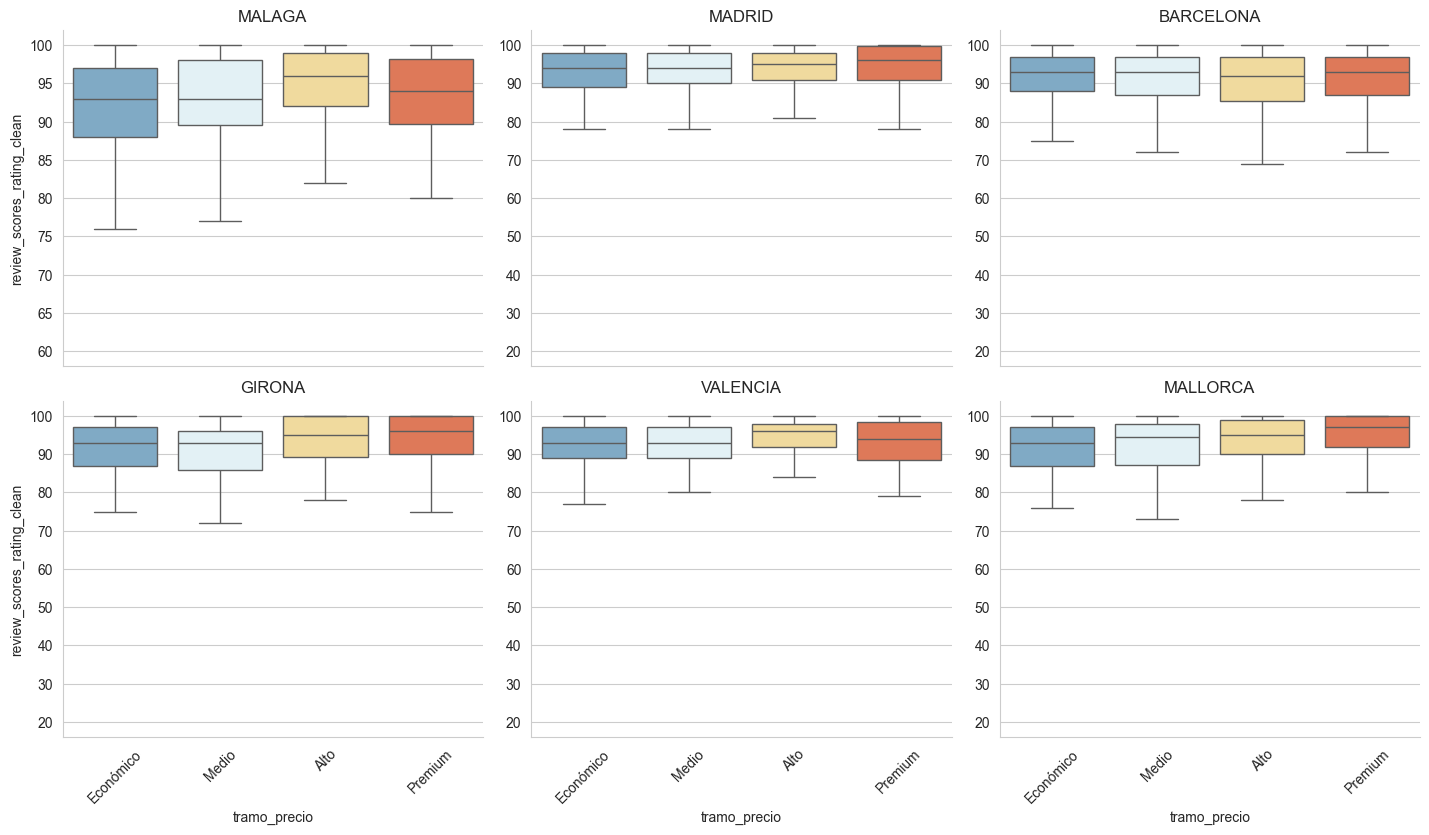

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definición de Tramos basada en Cuartiles Globales
# Calculamos los puntos de corte sobre todo el dataset
cuartiles = df_filtrado_price['price_imputed'].quantile([0.25, 0.5, 0.75]).values
bins = [0, cuartiles[0], cuartiles[1], cuartiles[2], float('inf')]
labels = ['Económico', 'Medio', 'Alto', 'Premium']

# Crear la nueva columna de tramos
df_filtrado_price['tramo_precio'] = pd.cut(df_filtrado_price['price_imputed'], 
                                          bins=bins, 
                                          labels=labels)

# 2. Visualización: Boxplots por Ciudad
# Seleccionamos las ciudades principales para que el gráfico sea legible
ciudades_foco = ['mallorca', 'girona', 'barcelona', 'valencia', 'madrid', 'malaga']
df_plot = df_filtrado_price[df_filtrado_price['city'].isin(ciudades_foco)]

plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

# Creamos un gráfico facetado (uno por ciudad)
g = sns.FacetGrid(df_plot, col="city", col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.boxplot, "tramo_precio", "review_scores_rating_clean", 
      order=labels, palette="RdYlBu_r", fliersize=0) # _r para que Azul sea Premium

# Ajustes estéticos
# Cambia tu línea 30 por esta:
g.set_titles("{col_name}") # Primero establecemos los títulos correctamente

# Y para que aparezcan en mayúsculas de forma segura, usa este bucle:
for ax in g.axes.flat:
    ax.set_title(ax.get_title().upper())
    ax.tick_params(axis='x', rotation=45)

### Conclusiones:

- El Éxito del Segmento Lujo (Girona, Mallorca y Madrid)

    Se observa una "escalera ascendente" clara. A medida que subimos de tramo (de Económico a Premium), la mediana del rating sube y la caja se vuelve más compacta en la parte superior. 
    
    En estas ciudades, el precio es un indicador de calidad. El cliente que paga por un servicio "Premium" efectivamente recibe una experiencia superior que se traduce en mejores notas

- El Problema del Tramo Medio (Valencia y Málaga)

    Valencia: Fíjate en cómo la caja del tramo Medio es casi idéntica a la del Económico, e incluso el tramo Premium baja ligeramente su mediana respecto al tramo Alto. 

    Málaga: Presenta una de las mayores variabilidades (bigotes muy largos hacia abajo). El tramo Medio tiene una dispersión enorme, lo que significa que la experiencia es "una lotería": puedes tener un 100 o un 75 pagando lo mismo.

    En estos mercados hay una crisis de expectativas. Los alojamientos de precio medio están cobrando más sin asegurar los estándares de limpieza o servicio que el cliente espera por ese precio.

- La Resistencia de Barcelona

    Es el gráfico más "plano". Apenas hay diferencia visual entre las medianas de los cuatro tramos. Incluso el tramo Premium muestra una dispersión de notas bajas (el bigote inferior) similar al tramo Económico.

    En Barcelona, pagar más no garantiza una mejor nota. El mercado está tan tensionado que el cliente Premium es extremadamente crítico, o bien la calidad de los pisos de lujo no está a la altura de su precio.

### Conclusiones:
Al analizar el gradiente, observamos que el tramo Premium lidera la satisfacción (media 92.74), mientras que el tramo Medio presenta el punto de inflexión más bajo (91.32). Dado que la dispersión (std) es constante en todos los niveles, el siguiente paso es la Regresión Múltiple Categórica. Esto nos permitirá confirmar si la ventaja del tramo Premium se debe al precio per se o si es porque esos alojamientos tienen mejores niveles de limpieza y precisión.

<span style="font-size: 1.5em;">Modelo de Regresión Lineal Múltiple.</span>

<span style="font-size: 1.5em;">Análisis relación entre rating general y precio.</span>

### Conclusiones:
### Relación entre el Precio y la Satisfacción General
El impacto del precio en la satisfacción general es marginal, indicándonos el modelo que una subida de 100€ en el precio tendría un impacto en la satisfaccion de 0.05 puntos. El hecho de que el coeficiente sea positivo sugiere que el cliente no "castiga" el precio alto, sino que en este mercado, el precio suele ser un indicador de una experiencia superior que el usuario valora positivamente.

<span style="font-size: 1.5em;">Modelo de Regresión lineal múltiple estandarizado.</span>

### Conclusiones:
### La precisión del anuncio y la limpieza, siguen siendo las variables que más impacto tienen sobre la valoración general.

- Precisión (3.5072): Es el factor determinante número uno. Una mejora en la veracidad del anuncio impacta casi 10 veces más que el precio.

- Limpieza (2.9368): El segundo pilar crítico. La higiene es fundamental para mantener el rating.

- Comunicación (1.4931): Tiene un impacto moderado, aproximadamente la mitad que la precisión.

- Check-in (0.7042): Aunque es positivo, su peso es menor en la experiencia global.

- Precio (0.3575): Es la variable con menor impacto de todas las analizadas.

Los alojamientos con precios más altos tienden a recibir mejores puntuaciones. Esto sugiere que el precio actúa como una "señal de calidad": el cliente paga más, pero recibe un valor que justifica y supera ese gasto. El precio no es una barrera para la satisfacción en este dataset.

La conclusión estratégica es clara: no necesitamos bajar precios para subir el rating; necesitamos asegurar que lo que el cliente ve en las fotos es exactamente lo que encuentra al llegar.

### Modelo de regresión múltiple con variable dummy

In [6]:
import statsmodels.api as sm
import pandas as pd

# 1. Definimos las variables independientes (X) y la dependiente (y)
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 2. Creamos las variables dummy (sin estandarizar)
# Usamos drop_first=True para que 'Económico' sea la base de referencia
df_dummies = pd.get_dummies(df_filtrado_price['tramo_precio'], drop_first=True).astype(float)

# 3. Concatenamos las variables continuas ORIGINALES con las dummies
# Importante: Aquí NO usamos el scaler, usamos el dataframe original
X_sin_escalar = pd.concat([df_filtrado_price[v_continuas], df_dummies], axis=1)

# 4. Limpieza de nulos (imprescindible para que el modelo no falle)
# Creamos un dataframe temporal para limpiar filas con NaNs en estas variables
df_temp = pd.concat([X_sin_escalar, df_filtrado_price['review_scores_rating_clean']], axis=1).dropna()

X_final = df_temp.drop(columns=['review_scores_rating_clean'])
y = df_temp['review_scores_rating_clean']

# 5. Añadimos la constante (intercepto) y ajustamos el modelo
X_final = sm.add_constant(X_final)
modelo_final = sm.OLS(y, X_final).fit()

# 6. Mostramos el resumen
print(modelo_final.summary())

                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.664
Model:                                    OLS   Adj. R-squared:                  0.664
Method:                         Least Squares   F-statistic:                     1980.
Date:                        Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                                10:43:20   Log-Likelihood:                -21676.
No. Observations:                        7009   AIC:                         4.337e+04
Df Residuals:                            7001   BIC:                         4.342e+04
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

### Modelo de regresión múltiple con variable dummy Estandarizado


In [12]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Definimos las variables continuas (asegúrate de tener esta lista definida)
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 2. LIMPIEZA PREVIA (Crucial para evitar errores de NaN en el StandardScaler)
df_filtrado_std = df_filtrado_price.dropna(subset=v_continuas + ['review_scores_rating_clean']).copy()

# 3. Creamos las variables dummy
df_dummies = pd.get_dummies(df_filtrado_std['tramo_precio'], drop_first=True).astype(float)

# 4. Preparamos el escalador para las variables continuas
scaler = StandardScaler()

# 5. Creamos un DataFrame con las variables continuas estandarizadas
df_scaled_std = pd.DataFrame(
    scaler.fit_transform(df_filtrado_std[v_continuas]),
    columns=v_continuas,
    index=df_filtrado_std.index
)

# 6. Concatenamos: Continuas escaladas + Dummies
X_estandarizada = pd.concat([df_scaled_std, df_dummies], axis=1)

# 7. Preparamos los datos finales para el modelo
# Usamos el dataframe limpio para que X e Y coincidan perfectamente
X_final_std = X_estandarizada
y_std = df_filtrado_std['review_scores_rating_clean']

# 8. Añadimos la constante (intercepto) y ajustamos el modelo
X_final_std = sm.add_constant(X_final_std)
modelo_std = sm.OLS(y_std, X_final_std).fit()

# 9. Mostramos el resumen
print("--- MODELO CON VARIABLES CONTINUAS ESTANDARIZADAS ---")
print(modelo_std.summary())

--- MODELO CON VARIABLES CONTINUAS ESTANDARIZADAS ---
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.664
Model:                                    OLS   Adj. R-squared:                  0.664
Method:                         Least Squares   F-statistic:                     1980.
Date:                        Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                                10:48:48   Log-Likelihood:                -21676.
No. Observations:                        7009   AIC:                         4.337e+04
Df Residuals:                            7001   BIC:                         4.342e+04
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t      P>|t|     

### Conclusiones:
### La precisión del anuncio y la limpieza, siguen siendo las variables que más impacto tienen sobre la valoración general.

- Precisión (3.5841): Es el factor determinante número uno. Una mejora en la veracidad del anuncio impacta casi 10 veces más que el precio.

- Limpieza (2.9567): El segundo pilar crítico. La higiene es fundamental para mantener el rating.

- Comunicación (1.6911): Tiene un impacto moderado, aproximadamente la mitad que la precisión.

- Check-in (0.718): Aunque es positivo, su peso es menor en la experiencia global.

- Tramo Premium (0.8220): Un alojamiento Premium obtiene, de media, 0.82 puntos más en su valoración general que uno Económico, incluso si ambos tuvieran la misma limpieza y precisión. Los clientes de este segmento no solo están dispuestos a pagar más, sino que su percepción de satisfacción es intrínsecamente mayor.

- Tramo Alto (0.2515): Estadísticamente, no podemos afirmar que el tramo Alto mejore la nota respecto al Económico de forma consistente. Ese ligero incremento de 0.25 puntos podría deberse al azar en esta muestra global.

- Tramo Medio (-0.3424): Hay una tendencia a que el tramo Medio reciba peores notas que el Económico. Este es el segmento más peligroso. El cliente del tramo medio suele ser más exigente que el del económico, pero no recibe el nivel de exclusividad del Premium.

Los alojamientos con precios más altos tienden a recibir mejores puntuaciones. Esto sugiere que el precio actúa como una "señal de calidad": el cliente paga más, pero recibe un valor que justifica y supera ese gasto. El precio no es una barrera para la satisfacción en este dataset.

La conclusión estratégica es clara: no necesitamos bajar precios para subir el rating; necesitamos asegurar que lo que el cliente ve en las fotos es exactamente lo que encuentra al llegar.

### Barcelona


In [11]:
# ==========================================
# SELECCIÓN MANUAL DE CIUDAD
# ==========================================
ciudad_a_analizar = 'barcelona'  # <--- Cambia aquí: 'madrid', 'mallorca', 'valencia', etc.

# 1. Filtramos el DataFrame por la ciudad elegida
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos las variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy para esa ciudad
# Usamos drop_first=True para que 'Económico' sea la referencia
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos todo
X_local = pd.concat([df_local[v_continuas], df_dummies_local], axis=1)
y_local = df_local['review_scores_rating_clean']

# 5. Limpiamos filas con nulos (fundamental para que no de error)
df_temp_local = pd.concat([X_local, y_local], axis=1).dropna()

X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 6. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 7. RESULTADOS
print(f"--- ANÁLISIS DETALLADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(modelo_local.summary())

--- ANÁLISIS DETALLADO PARA: BARCELONA ---
Registros analizados: 2079
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.699
Model:                                    OLS   Adj. R-squared:                  0.698
Method:                         Least Squares   F-statistic:                     687.6
Date:                        Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                                23:24:28   Log-Likelihood:                -6287.7
No. Observations:                        2079   AIC:                         1.259e+04
Df Residuals:                            2071   BIC:                         1.264e+04
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t

### Conclusiones

Un apartamento de lujo en Barcelona no saca mejor nota que uno económico por el hecho de ser caro. El cliente de Barcelona es "agnóstico" al precio; juzga la experiencia real, no el estatus del alojamiento.

Precisión y limpieza son las palancas que hacen que la satisfacción general suba


### Valencia

In [12]:
# ==========================================
# SELECCIÓN MANUAL DE CIUDAD
# ==========================================
ciudad_a_analizar = 'valencia'  # <--- Cambia aquí: 'madrid', 'mallorca', 'valencia', etc.

# 1. Filtramos el DataFrame por la ciudad elegida
df_local_val = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos las variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy para esa ciudad
# Usamos drop_first=True para que 'Económico' sea la referencia
df_dummies_local_val = pd.get_dummies(df_local_val['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos todo
X_local_val = pd.concat([df_local_val[v_continuas], df_dummies_local_val], axis=1)
y_local_val = df_local_val['review_scores_rating_clean']

# 5. Limpiamos filas con nulos (fundamental para que no de error)
df_temp_local_val = pd.concat([X_local_val, y_local_val], axis=1).dropna()

X_final_local_val = df_temp_local_val.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local_val['review_scores_rating_clean']

# 6. Añadimos la constante y ejecutamos el modelo
X_final_local_val = sm.add_constant(X_final_local_val)
modelo_local = sm.OLS(y_final_local, X_final_local_val).fit()

# 7. RESULTADOS
print(f"--- ANÁLISIS DETALLADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local_val)}")
print(modelo_local.summary())

--- ANÁLISIS DETALLADO PARA: VALENCIA ---
Registros analizados: 428
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.680
Model:                                    OLS   Adj. R-squared:                  0.675
Method:                         Least Squares   F-statistic:                     127.8
Date:                        Wed, 06 May 2026   Prob (F-statistic):          6.74e-100
Time:                                23:40:13   Log-Likelihood:                -1272.4
No. Observations:                         428   AIC:                             2561.
Df Residuals:                             420   BIC:                             2593.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t  

### Conclusiones

A igualdad de limpieza y servicio, un apartamento de precio medio en Valencia saca 1.5 puntos menos de rating que uno económico.

Existe una brecha de expectativas crítica. El cliente que paga un precio "intermedio" en Valencia es el más severo; probablemente siente que está pagando un sobrecoste que no se traduce en una experiencia superior

### Menorca

In [15]:
ciudad_a_analizar = 'menorca'
# 1. Filtramos el DataFrame por la ciudad elegida
df_local_men = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 3. Creamos las variables dummy para esa ciudad
# Usamos drop_first=True para que 'Económico' sea la referencia
df_dummies_local_men = pd.get_dummies(df_local_men['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos todo
X_local_men = pd.concat([df_local_men[v_continuas], df_dummies_local_men], axis=1)
y_local_men = df_local_men['review_scores_rating_clean']

# 5. Limpiamos filas con nulos (fundamental para que no de error)
df_temp_local_men = pd.concat([X_local_men, y_local_men], axis=1).dropna()

X_final_local_men = df_temp_local_men.drop(columns=['review_scores_rating_clean'])
y_final_local_men = df_temp_local_men['review_scores_rating_clean']

# 6. Añadimos la constante y ejecutamos el modelo
X_final_local_men = sm.add_constant(X_final_local_men)
modelo_local_men = sm.OLS(y_final_local_men, X_final_local_men).fit()

# 7. RESULTADOS
print(f"--- ANÁLISIS DETALLADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local_men)}")
print(modelo_local_men.summary())

--- ANÁLISIS DETALLADO PARA: MENORCA ---
Registros analizados: 144
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.675
Model:                                    OLS   Adj. R-squared:                  0.659
Method:                         Least Squares   F-statistic:                     40.44
Date:                        Wed, 06 May 2026   Prob (F-statistic):           2.71e-30
Time:                                23:45:59   Log-Likelihood:                -435.32
No. Observations:                         144   AIC:                             886.6
Df Residuals:                             136   BIC:                             910.4
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t   

### Conclusiones

Si comparamos dos apartamentos con la misma limpieza y el mismo servicio, el que está en el tramo Medio saca 3.2 puntos menos de rating que el Económico. 

En Menorca, el cliente del tramo medio es extremadamente crítico. Es probable que en una isla con expectativas de "paraíso", quien paga un precio intermedio espere una exclusividad que no está recibiendo

### Málaga

In [20]:
ciudad_a_analizar = 'malaga'
# 1. Filtramos el DataFrame por la ciudad elegida
df_local_mal = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 3. Creamos las variables dummy para esa ciudad
# Usamos drop_first=True para que 'Económico' sea la referencia
df_dummies_local_mal = pd.get_dummies(df_local_mal['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos todo
X_local_mal = pd.concat([df_local_mal[v_continuas], df_dummies_local_mal], axis=1)
y_local_mal = df_local_mal['review_scores_rating_clean']

# 5. Limpiamos filas con nulos (fundamental para que no de error)
df_temp_local_mal = pd.concat([X_local_mal, y_local_mal], axis=1).dropna()

X_final_local_mal = df_temp_local_mal.drop(columns=['review_scores_rating_clean'])
y_final_local_mal = df_temp_local_mal['review_scores_rating_clean']

# 6. Añadimos la constante y ejecutamos el modelo
X_final_local_mal = sm.add_constant(X_final_local_mal)
modelo_local_mal = sm.OLS(y_final_local_mal, X_final_local_mal).fit()

# 7. RESULTADOS
print(f"--- ANÁLISIS DETALLADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local_mal)}")
print(modelo_local_mal.summary())

--- ANÁLISIS DETALLADO PARA: MALAGA ---
Registros analizados: 415
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.639
Model:                                    OLS   Adj. R-squared:                  0.633
Method:                         Least Squares   F-statistic:                     102.8
Date:                        Wed, 06 May 2026   Prob (F-statistic):           5.88e-86
Time:                                23:57:32   Log-Likelihood:                -1215.4
No. Observations:                         415   AIC:                             2447.
Df Residuals:                             407   BIC:                             2479.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t    

### Conclusiones

Ninguno de los tramos de precio es estadísticamente significativo (todos tienen p-valores > 0.05). 

En Málaga, cobrar más no te garantiza una mejor valoración, pero tampoco te penaliza. El cliente de Málaga no juzga el alojamiento por su "etiqueta de precio", sino por lo que recibe a cambio

### Mallorca

In [17]:
ciudad_a_analizar = 'mallorca'
# 1. Filtramos el DataFrame por la ciudad elegida
df_local_mall = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 3. Creamos las variables dummy para esa ciudad
# Usamos drop_first=True para que 'Económico' sea la referencia
df_dummies_local_mall = pd.get_dummies(df_local_mall['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos todo
X_local_mall = pd.concat([df_local_mall[v_continuas], df_dummies_local_mall], axis=1)
y_local_mall = df_local_mall['review_scores_rating_clean']

# 5. Limpiamos filas con nulos (fundamental para que no de error)
df_temp_local_mall = pd.concat([X_local_mall, y_local_mall], axis=1).dropna()

X_final_local_mall = df_temp_local_mall.drop(columns=['review_scores_rating_clean'])
y_final_local_mall = df_temp_local_mall['review_scores_rating_clean']

# 6. Añadimos la constante y ejecutamos el modelo
X_final_local_mall = sm.add_constant(X_final_local_mall)
modelo_local_mall = sm.OLS(y_final_local_mall, X_final_local_mall).fit()

# 7. RESULTADOS
print(f"--- ANÁLISIS DETALLADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local_mall)}")
print(modelo_local_mall.summary())

--- ANÁLISIS DETALLADO PARA: MALLORCA ---
Registros analizados: 970
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.705
Model:                                    OLS   Adj. R-squared:                  0.703
Method:                         Least Squares   F-statistic:                     328.7
Date:                        Wed, 06 May 2026   Prob (F-statistic):          4.88e-250
Time:                                23:46:53   Log-Likelihood:                -3015.1
No. Observations:                         970   AIC:                             6046.
Df Residuals:                             962   BIC:                             6085.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t  

### Conclusiones

Manteniendo la limpieza y el servicio constantes, un alojamiento Premium saca 1.8 puntos más de rating que uno Económico.

En Mallorca existe un "bono de satisfacción" por el lujo. Los clientes del segmento más alto no solo pagan más, sino que su percepción de la experiencia es intrínsecamente más positiva.


### Girona

In [18]:
ciudad_a_analizar = 'girona'
# 1. Filtramos el DataFrame por la ciudad elegida
df_local_gir = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 3. Creamos las variables dummy para esa ciudad
# Usamos drop_first=True para que 'Económico' sea la referencia
df_dummies_local_gir = pd.get_dummies(df_local_gir['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos todo
X_local_gir = pd.concat([df_local_gir[v_continuas], df_dummies_local_gir], axis=1)
y_local_gir = df_local_gir['review_scores_rating_clean']

# 5. Limpiamos filas con nulos (fundamental para que no de error)
df_temp_local_gir = pd.concat([X_local_gir, y_local_gir], axis=1).dropna()

X_final_local_gir = df_temp_local_gir.drop(columns=['review_scores_rating_clean'])
y_final_local_gir = df_temp_local_gir['review_scores_rating_clean']

# 6. Añadimos la constante y ejecutamos el modelo
X_final_local_gir = sm.add_constant(X_final_local_gir)
modelo_local_gir = sm.OLS(y_final_local_gir, X_final_local_gir).fit()

# 7. RESULTADOS
print(f"--- ANÁLISIS DETALLADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local_gir)}")
print(modelo_local_gir.summary())
# 6. Mostramos el resumen

--- ANÁLISIS DETALLADO PARA: GIRONA ---
Registros analizados: 902
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.555
Model:                                    OLS   Adj. R-squared:                  0.552
Method:                         Least Squares   F-statistic:                     159.4
Date:                        Wed, 06 May 2026   Prob (F-statistic):          1.67e-152
Time:                                23:50:11   Log-Likelihood:                -3080.3
No. Observations:                         902   AIC:                             6177.
Df Residuals:                             894   BIC:                             6215.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t    

### Conclusiones

Un alojamiento Premium en Girona obtiene 3.3 puntos más de rating que uno Económico, incluso si tienen la misma limpieza y servicio.

El cliente que elige este destino busca exclusividad y, cuando la paga, su percepción de la experiencia se dispara positivamente. Es un mercado donde la marca "Premium" tiene un valor reputacional inmenso.

### Madrid

In [19]:
ciudad_a_analizar = 'madrid'
# 1. Filtramos el DataFrame por la ciudad elegida
df_local_mad = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 3. Creamos las variables dummy para esa ciudad
# Usamos drop_first=True para que 'Económico' sea la referencia
df_dummies_local_mad = pd.get_dummies(df_local_mad['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos todo
X_local_mad = pd.concat([df_local_mad[v_continuas], df_dummies_local_mad], axis=1)
y_local_mad = df_local_mad['review_scores_rating_clean']

# 5. Limpiamos filas con nulos (fundamental para que no de error)
df_temp_local_mad = pd.concat([X_local_mad, y_local_mad], axis=1).dropna()

X_final_local_mad = df_temp_local_mad.drop(columns=['review_scores_rating_clean'])
y_final_local_mad = df_temp_local_mad['review_scores_rating_clean']

# 6. Añadimos la constante y ejecutamos el modelo
X_final_local_mad = sm.add_constant(X_final_local_mad)
modelo_local_mad = sm.OLS(y_final_local_mad, X_final_local_mad).fit()

# 7. RESULTADOS
print(f"--- ANÁLISIS DETALLADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local_mad)}")
print(modelo_local_mad.summary())
# 6. Mostramos el resumen

--- ANÁLISIS DETALLADO PARA: MADRID ---
Registros analizados: 1644
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.702
Model:                                    OLS   Adj. R-squared:                  0.701
Method:                         Least Squares   F-statistic:                     551.6
Date:                        Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                                23:52:54   Log-Likelihood:                -4882.0
No. Observations:                        1644   AIC:                             9780.
Df Residuals:                            1636   BIC:                             9823.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                  coef    std err          t   

### Conclusiones

- Tramo Premium (0.71): Los alojamientos de lujo en Madrid logran una mejor valoración que los económicos, lo que indica que el cliente Premium en la capital siente que el servicio justifica el precio.

- Tramo Alto (+0.63): Es una señal excelente: Madrid es una ciudad donde invertir en subir de categoría el alojamiento tiene una recompensa directa en reputación.

### Conclusiones Generales

- Tramo Premium

    Este tramo es el más consistente y positivo en casi todo tu estudio.

    Ciudades Líderes: En Girona (+3.29) y Mallorca (+1.83), ser Premium es la estrategia ganadora. En estos destinos vacacionales, el cliente asocia el precio alto con una experiencia superior y "premia" al anfitrión con notas mucho más altas.

    Madrid (+0.71): También es positivo y significativo, aunque el impacto es más moderado que en la costa, indicando un mercado de lujo más competitivo y maduro

- Tramo Alto

    Éxito en Girona (+2.49) y Madrid (+0.63): En estos mercados, el tramo Alto funciona bien. El cliente percibe que está pagando por una calidad superior y responde positivamente.

- Tramo Medio

    Menorca (-3.23) y Valencia (-1.54): Son los casos más críticos. Aquí, situarse en el tramo medio es "tierra de nadie". El cliente paga más que en el económico (lo que sube su exigencia), pero no percibe el valor diferencial del lujo, resultando en las peores notas de todo el estudio




In [18]:
import pandas as pd

# 1. Preparación de los datos con los resultados de tus modelos
data_final = {
    'Ciudad': ['Girona', 'Mallorca', 'Madrid', 'Málaga', 'Valencia', 'Menorca'],
    'Tramo Medio': [0.85, 0.10, 0.18, 0.25, -1.54, -3.23],
    'Tramo Alto': [2.50, 0.02, 0.63, 0.96, 0.44, -2.45],
    'Tramo Premium': [3.30, 1.83, 0.72, 1.44, 0.16, -1.87],
    'Limpieza': [0.34, 0.29, 0.29, 0.33, 0.41, 0.32],
    'Exactitud': [0.33, 0.43, 0.31, 0.33, 0.43, 0.56],
    'Comunicación': [0.16, 0.19, 0.29, 0.04, 0.08, 0.44]
}

df_resumen = pd.DataFrame(data_final).set_index('Ciudad')

# 2. Definición de estilos inspirados en tu gráfico
def styler_spearman(styler):
    # Fondo transparente y fuente Helvetica
    styler.set_properties(**{
        'background-color': 'rgba(0,0,0,0)',
        'font-family': 'Helvetica',
        'font-size': '16px',
        'color': '#555555',
        'border': 'none',
        'padding': '12px'
    })
    
    # Estilo de las cabeceras (parecido a tus etiquetas del eje X)
    styler.set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', 'rgba(0,0,0,0)'),
            ('color', '#888888'),
            ('font-weight', 'normal'),
            ('border-bottom', '1px solid #cccccc'),
            ('font-size', '18px')
        ]},
        {'selector': 'table', 'props': [('background-color', 'rgba(0,0,0,0)'), ('border-collapse', 'collapse')]}
    ])

    # Colores condicionales: Azul para los que impulsan el rating (>0.5) y Coral para alertas (< -1)
    def color_logic(val):
        if val > 1.5: return 'color: #2C7BB6; font-weight: bold' # Azul fuerte (Girona/Mallorca Premium)
        if val < -1.5: return 'color: lightcoral; font-weight: bold' # Coral (Menorca/Valencia Medio)
        return 'color: #555555'
    
    styler.applymap(color_logic)
    return styler

# 3. Mostrar la tabla
tabla_transparente = df_resumen.style.pipe(styler_spearman).format("{:.2f}")
tabla_transparente

# Primero instala la librería si no la tienes: !pip install dataframe_image
import dataframe_image as dfi

# Aplicamos el estilo que definimos (el fondo es transparente por defecto en la exportación)
tabla_final = df_resumen.style.pipe(styler_spearman).format("{:.2f}")

# Guardamos como PNG
dfi.export(tabla_final, 'tabla_coeficientes_final.png', table_conversion='chrome')

C:\Users\ruben\AppData\Local\Temp\ipykernel_25180\973819903.py:46: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styler.applymap(color_logic)
C:\Users\ruben\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
C:\Users\ruben\AppData\Local\Temp\ipykernel_25180\973819903.py:46: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styler.applymap(color_logic)


In [19]:
import os
print(os.getcwd())

c:\Simulador_Análisis_datos\Sprint 3


In [17]:
!pip install dataframe_image


^C



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\ruben\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------- ----------- 4.7/6.7 MB 24.3 MB/s eta 0:00:01
   ---------------------------------------- 6.7/6.7 MB 21.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 22.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/37.7 MB ? eta -:--:--
   ------ --------------------------------- 6.3/37.7 MB 29.6 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/37.7 MB 31.7 MB/s eta 0:00:01
   ---------------------- ----------------- 21.0/37.7 MB 34.2 MB/s eta 0:00:01
   ------------------------------- -------- 29.9/37.7 MB 34.8 MB/s eta 0:00:01
   ---------------------------------------  37.5/37.7 MB 36.7 MB/s eta 0:00:01
   ---------------------------------------  37.5/37.7 MB 36.7 MB/s eta 0:00:01
   -------

In [26]:
def comparar_modelos_significativos(df, v_continuas):
    resultados_ciudades = []
    
    for ciudad in df['city'].unique():
        df_c = df[df['city'] == ciudad].copy()
        
        if len(df_c) > 100:
            df_dummies = pd.get_dummies(df_c['tramo_precio'], drop_first=True).astype(float)
            X = pd.concat([df_c[v_continuas], df_dummies], axis=1)
            y = df_c['review_scores_rating_clean']
            
            df_temp = pd.concat([X, y], axis=1).dropna()
            if not df_temp.empty:
                X_final = sm.add_constant(df_temp.drop(columns=['review_scores_rating_clean']))
                y_final = df_temp['review_scores_rating_clean']
                
                mod = sm.OLS(y_final, X_final).fit()
                
                # Guardamos solo si p-value < 0.05
                res = {'Ciudad': ciudad, 'N': len(df_temp)}
                
                for var in ['Medio', 'Alto', 'Premium']:
                    if var in mod.pvalues and mod.pvalues[var] < 0.05:
                        res[var] = round(mod.params[var], 3)
                    else:
                        res[var] = "N.S." # No Significativo
                
                resultados_ciudades.append(res)

    return pd.DataFrame(resultados_ciudades)
# Llamamos a la función y guardamos el resultado en una variable global
df_resultados_final = comparar_modelos_significativos(df_filtrado_price, v_continuas)

# Mostramos el DataFrame resultante
df_resultados_final

,Ciudad,N,Medio,Alto,Premium
0,malaga,415,N.S.,N.S.,N.S.
1,madrid,1644,N.S.,0.632,0.717
2,sevilla,427,N.S.,N.S.,N.S.
3,barcelona,2079,N.S.,N.S.,N.S.
4,girona,902,N.S.,2.498,3.298
5,valencia,428,-1.547,N.S.,N.S.
6,mallorca,970,N.S.,N.S.,1.832
7,menorca,144,N.S.,N.S.,N.S.


In [83]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'barcelona'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: BARCELONA ---
Registros analizados: 2079
R-squared del modelo: 0.699
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.699
Model:                                    OLS   Adj. R-squared:                  0.698
Method:                         Least Squares   F-statistic:                     687.6
Date:                        Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                                14:33:50   Log-Likelihood:                -6287.7
No. Observations:                        2079   AIC:                         1.259e+04
Df Residuals:                            2071   BIC:                         1.264e+04
Df Model:                                   7                                         
Covariance Type:                    nonrobust                   

In [84]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'mallorca'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: MALLORCA ---
Registros analizados: 970
R-squared del modelo: 0.705
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.705
Model:                                    OLS   Adj. R-squared:                  0.703
Method:                         Least Squares   F-statistic:                     328.7
Date:                        Thu, 07 May 2026   Prob (F-statistic):          4.88e-250
Time:                                14:34:43   Log-Likelihood:                -3015.1
No. Observations:                         970   AIC:                             6046.
Df Residuals:                             962   BIC:                             6085.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                     

In [85]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'menorca'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: MENORCA ---
Registros analizados: 144
R-squared del modelo: 0.675
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.675
Model:                                    OLS   Adj. R-squared:                  0.659
Method:                         Least Squares   F-statistic:                     40.44
Date:                        Thu, 07 May 2026   Prob (F-statistic):           2.71e-30
Time:                                14:35:26   Log-Likelihood:                -435.32
No. Observations:                         144   AIC:                             886.6
Df Residuals:                             136   BIC:                             910.4
Df Model:                                   7                                         
Covariance Type:                    nonrobust                      

In [87]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'valencia'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: VALENCIA ---
Registros analizados: 428
R-squared del modelo: 0.680
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.680
Model:                                    OLS   Adj. R-squared:                  0.675
Method:                         Least Squares   F-statistic:                     127.8
Date:                        Thu, 07 May 2026   Prob (F-statistic):          6.74e-100
Time:                                14:36:44   Log-Likelihood:                -1272.4
No. Observations:                         428   AIC:                             2561.
Df Residuals:                             420   BIC:                             2593.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                     

In [88]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'malaga'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: MALAGA ---
Registros analizados: 415
R-squared del modelo: 0.639
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.639
Model:                                    OLS   Adj. R-squared:                  0.633
Method:                         Least Squares   F-statistic:                     102.8
Date:                        Thu, 07 May 2026   Prob (F-statistic):           5.88e-86
Time:                                14:37:39   Log-Likelihood:                -1215.4
No. Observations:                         415   AIC:                             2447.
Df Residuals:                             407   BIC:                             2479.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                       

In [89]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'girona'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: GIRONA ---
Registros analizados: 902
R-squared del modelo: 0.555
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.555
Model:                                    OLS   Adj. R-squared:                  0.552
Method:                         Least Squares   F-statistic:                     159.4
Date:                        Thu, 07 May 2026   Prob (F-statistic):          1.67e-152
Time:                                14:38:16   Log-Likelihood:                -3080.3
No. Observations:                         902   AIC:                             6177.
Df Residuals:                             894   BIC:                             6215.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                       

In [90]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'sevilla'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: SEVILLA ---
Registros analizados: 427
R-squared del modelo: 0.746
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.746
Model:                                    OLS   Adj. R-squared:                  0.742
Method:                         Least Squares   F-statistic:                     176.0
Date:                        Thu, 07 May 2026   Prob (F-statistic):          1.56e-120
Time:                                14:41:11   Log-Likelihood:                -1149.7
No. Observations:                         427   AIC:                             2315.
Df Residuals:                             419   BIC:                             2348.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                      

In [95]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

ciudad_a_analizar = 'madrid'

# 1. Filtramos el DataFrame
df_local = df_filtrado_price[df_filtrado_price['city'] == ciudad_a_analizar].copy()

# 2. Definimos variables operativas
v_continuas = [
    'review_scores_cleanliness', 
    'review_scores_accuracy', 
    'review_scores_communication', 
    'review_scores_checkin'
]

# 3. Creamos las variables dummy (Referencia: Económico)
df_dummies_local = pd.get_dummies(df_local['tramo_precio'], drop_first=True).astype(float)

# 4. Concatenamos para limpiar nulos primero
df_temp_local = pd.concat([df_local[v_continuas], df_dummies_local, df_local['review_scores_rating_clean']], axis=1).dropna()

# --- 5. ESTANDARIZACIÓN DE VARIABLES CONTINUAS ---
# Creamos el escalador
scaler = StandardScaler()

# Solo ajustamos y transformamos las variables de valoración (v_continuas)
df_temp_local[v_continuas] = scaler.fit_transform(df_temp_local[v_continuas])

# 6. Preparamos X e y finales
X_final_local = df_temp_local.drop(columns=['review_scores_rating_clean'])
y_final_local = df_temp_local['review_scores_rating_clean']

# 7. Añadimos la constante y ejecutamos el modelo
X_final_local = sm.add_constant(X_final_local)
modelo_local = sm.OLS(y_final_local, X_final_local).fit()

# 8. RESULTADOS
print(f"--- ANÁLISIS ESTANDARIZADO PARA: {ciudad_a_analizar.upper()} ---")
print(f"Registros analizados: {len(df_temp_local)}")
print(f"R-squared del modelo: {modelo_local.rsquared:.3f}")
print("-" * 50)
print(modelo_local.summary())

--- ANÁLISIS ESTANDARIZADO PARA: MADRID ---
Registros analizados: 1644
R-squared del modelo: 0.702
--------------------------------------------------
                                OLS Regression Results                                
Dep. Variable:     review_scores_rating_clean   R-squared:                       0.702
Model:                                    OLS   Adj. R-squared:                  0.701
Method:                         Least Squares   F-statistic:                     551.6
Date:                        Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                                15:05:56   Log-Likelihood:                -4882.0
No. Observations:                        1644   AIC:                             9780.
Df Residuals:                            1636   BIC:                             9823.
Df Model:                                   7                                         
Covariance Type:                    nonrobust                      

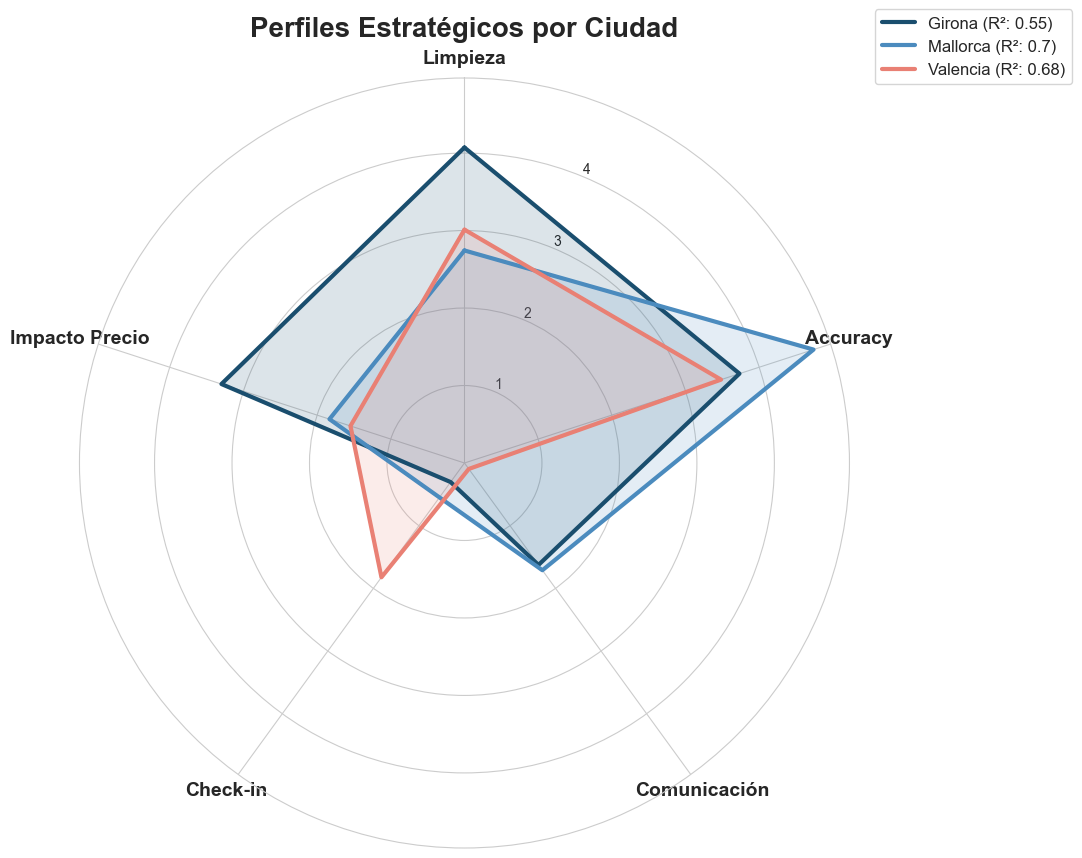

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Datos normalizados para la comparativa (Escala 0-5 basada en tus coeficientes)
# Nota: Para el precio negativo de Valencia, usamos su valor absoluto para mostrar 'importancia'
labels = ['Limpieza', 'Accuracy', 'Comunicación', 'Check-in', 'Impacto Precio']
ciudades = {
    'Girona': [4.072, 3.732, 1.626, 0.304, 3.298],
    'Mallorca': [2.743, 4.737, 1.711, 0.549, 1.832],
    'Valencia': [3.012, 3.482, 0.095, 1.823, 1.547]
}

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_alpha(0) # Fondo transparente
ax.set_facecolor('none')

colors = ['#1A4E6E', '#4B8BBE', '#E98074'] # Paleta profesional

for i, (ciudad, data) in enumerate(ciudades.items()):
    values = data + data[:1]
    ax.plot(angles, values, color=colors[i], linewidth=3, label=f"{ciudad} (R²: { [0.55, 0.70, 0.68][i] })")
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=14, weight='bold')

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.title("Perfiles Estratégicos por Ciudad", size=20, pad=30, weight='bold')
plt.show()